In [1]:
import os, time, warnings, pickle, json
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance, UnidentifiedImageError

from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
from skimage.color import rgb2gray, rgb2lab
from skimage.filters import gabor_kernel
from scipy.ndimage import convolve
from scipy.stats import skew

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV, StratifiedKFold)
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')
print('Library imported.')


Library imported.


In [2]:
DATASET_ROOT = Path('/kaggle/input/datasets/shijo96john/facial-skin-acne-pigmentation-pores-wrinkles/dataset')
OUTPUT_DIR   = Path('/kaggle/working')
VALID_EXT    = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tiff'}
IMG_SIZE     = (128, 128)
RANDOM_STATE = 42
TEST_SIZE    = 0.2

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f'Dataset tidak ditemukan: {DATASET_ROOT}')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_DIRS  = sorted([d for d in DATASET_ROOT.iterdir() if d.is_dir()])
CLASS_NAMES = [d.name for d in CLASS_DIRS]
NUM_CLASSES = len(CLASS_NAMES)

print(f'Config: {NUM_CLASSES} kelas')
for i, c in enumerate(CLASS_NAMES):
    n = len([f for f in CLASS_DIRS[i].iterdir() if f.suffix.lower() in VALID_EXT])
    print(f'   [{i}] {c:<45} ({n} gambar)')


Config: 8 kelas
   [0] Redness                                       (600 gambar)
   [1] dark spots                                    (619 gambar)
   [2] inflammatory acne                             (603 gambar)
   [3] non inflammatory acne black heads             (312 gambar)
   [4] non inflammatory acne white heads             (300 gambar)
   [5] pigmentation                                  (599 gambar)
   [6] pores                                         (600 gambar)
   [7] wrinkles                                      (600 gambar)


In [3]:
def load_and_preprocess(filepath: Path, img_size: tuple):
    try:
        img = Image.open(filepath).convert('RGB')
        img = img.resize(img_size, Image.LANCZOS)
        return np.array(img, dtype=np.float32) / 255.0
    except Exception:
        return None

def augment_image(img_arr: np.ndarray) -> list:
    """
    Hasilkan 3 augmentasi dari 1 gambar:
      1. Horizontal flip
      2. Brightness sedikit lebih cerah (+20%)
      3. Brightness sedikit lebih gelap (-20%)

    Kenapa augmentasi ini?
    - Kondisi kulit tidak berubah saat di-flip horizontal
    - Pencahayaan foto kulit sangat bervariasi (selfie vs studio vs outdoor)
    - Augmentasi sederhana = lebih stabil dari augmentasi agresif (rotation, zoom)
    - 3x lipat dataset: ~4000 → ~16000 sampel training
    """
    pil_img = Image.fromarray((img_arr * 255).astype(np.uint8))
    augs = []

    # Flip horizontal
    flipped = np.array(pil_img.transpose(Image.FLIP_LEFT_RIGHT), dtype=np.float32) / 255.0
    augs.append(flipped)

    # Brightness +20%
    bright = np.array(ImageEnhance.Brightness(pil_img).enhance(1.2),
                       dtype=np.float32) / 255.0
    augs.append(np.clip(bright, 0, 1))

    # Brightness -20%
    dark = np.array(ImageEnhance.Brightness(pil_img).enhance(0.8),
                     dtype=np.float32) / 255.0
    augs.append(np.clip(dark, 0, 1))

    return augs


In [4]:
print('Loading gambar...')
images_rgb_orig, labels_raw_orig = [], []
skipped = 0

for cls_dir in CLASS_DIRS:
    cls_name = cls_dir.name
    files = sorted([f for f in cls_dir.iterdir() if f.suffix.lower() in VALID_EXT])
    for fp in tqdm(files, desc=f'  {cls_name[:30]:<30}', leave=False):
        arr = load_and_preprocess(fp, IMG_SIZE)
        if arr is not None:
            images_rgb_orig.append(arr)
            labels_raw_orig.append(cls_name)
        else:
            skipped += 1

images_rgb_orig = np.array(images_rgb_orig, dtype=np.float32)
labels_raw_orig = np.array(labels_raw_orig)

print(f'Original: {len(images_rgb_orig)} gambar (skip={skipped})')


Loading gambar...


  Redness                       :   0%|          | 0/600 [00:00<?, ?it/s]

  dark spots                    :   0%|          | 0/619 [00:00<?, ?it/s]

  inflammatory acne             :   0%|          | 0/603 [00:00<?, ?it/s]

  non inflammatory acne black he:   0%|          | 0/312 [00:00<?, ?it/s]

  non inflammatory acne white he:   0%|          | 0/300 [00:00<?, ?it/s]

  pigmentation                  :   0%|          | 0/599 [00:00<?, ?it/s]

  pores                         :   0%|          | 0/600 [00:00<?, ?it/s]

  wrinkles                      :   0%|          | 0/600 [00:00<?, ?it/s]

Original: 4233 gambar (skip=0)


In [5]:
# Split dulu SEBELUM augmentasi — PENTING!
# Augmentasi hanya pada train set agar test set tetap "bersih"
le_pre = LabelEncoder()
y_orig = le_pre.fit_transform(labels_raw_orig)

idx_train, idx_test = train_test_split(
    np.arange(len(images_rgb_orig)), test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=y_orig
)

imgs_train_orig = images_rgb_orig[idx_train]
lbls_train_orig = labels_raw_orig[idx_train]
imgs_test        = images_rgb_orig[idx_test]
lbls_test        = labels_raw_orig[idx_test]

print(f'Split awal: train={len(imgs_train_orig)}, test={len(imgs_test)}')
print()
print('Augmentasi training set (×3)...')

imgs_train_aug = list(imgs_train_orig)
lbls_train_aug = list(lbls_train_orig)

for img, lbl in tqdm(zip(imgs_train_orig, lbls_train_orig),
                      total=len(imgs_train_orig), desc='Augmenting'):
    for aug_img in augment_image(img):
        imgs_train_aug.append(aug_img)
        lbls_train_aug.append(lbl)

imgs_train_aug = np.array(imgs_train_aug, dtype=np.float32)
lbls_train_aug = np.array(lbls_train_aug)

print(f'Train set setelah augmentasi: {len(imgs_train_aug)}')
print(f'   (dari {len(imgs_train_orig)} → ×4 = {len(imgs_train_orig)*4})')
print()

# Distribusi kelas setelah augmentasi
le = LabelEncoder()
le.fit(labels_raw_orig)
y_train = le.transform(lbls_train_aug)
y_test  = le.transform(lbls_test)
print('Distribusi train set setelah augmentasi:')
for cls, cnt in zip(le.classes_, np.bincount(y_train)):
    print(f'   {cls[:40]:<40}: {cnt:>5}  {"█"*(cnt//30)}')


Split awal: train=3386, test=847

Augmentasi training set (×3)...


Augmenting:   0%|          | 0/3386 [00:00<?, ?it/s]

Train set setelah augmentasi: 13544
   (dari 3386 → ×4 = 13544)

Distribusi train set setelah augmentasi:
   Redness                                 :  1920  ████████████████████████████████████████████████████████████████
   dark spots                              :  1980  ██████████████████████████████████████████████████████████████████
   inflammatory acne                       :  1928  ████████████████████████████████████████████████████████████████
   non inflammatory acne black heads       :  1000  █████████████████████████████████
   non inflammatory acne white heads       :   960  ████████████████████████████████
   pigmentation                            :  1916  ███████████████████████████████████████████████████████████████
   pores                                   :  1920  ████████████████████████████████████████████████████████████████
   wrinkles                                :  1920  ████████████████████████████████████████████████████████████████


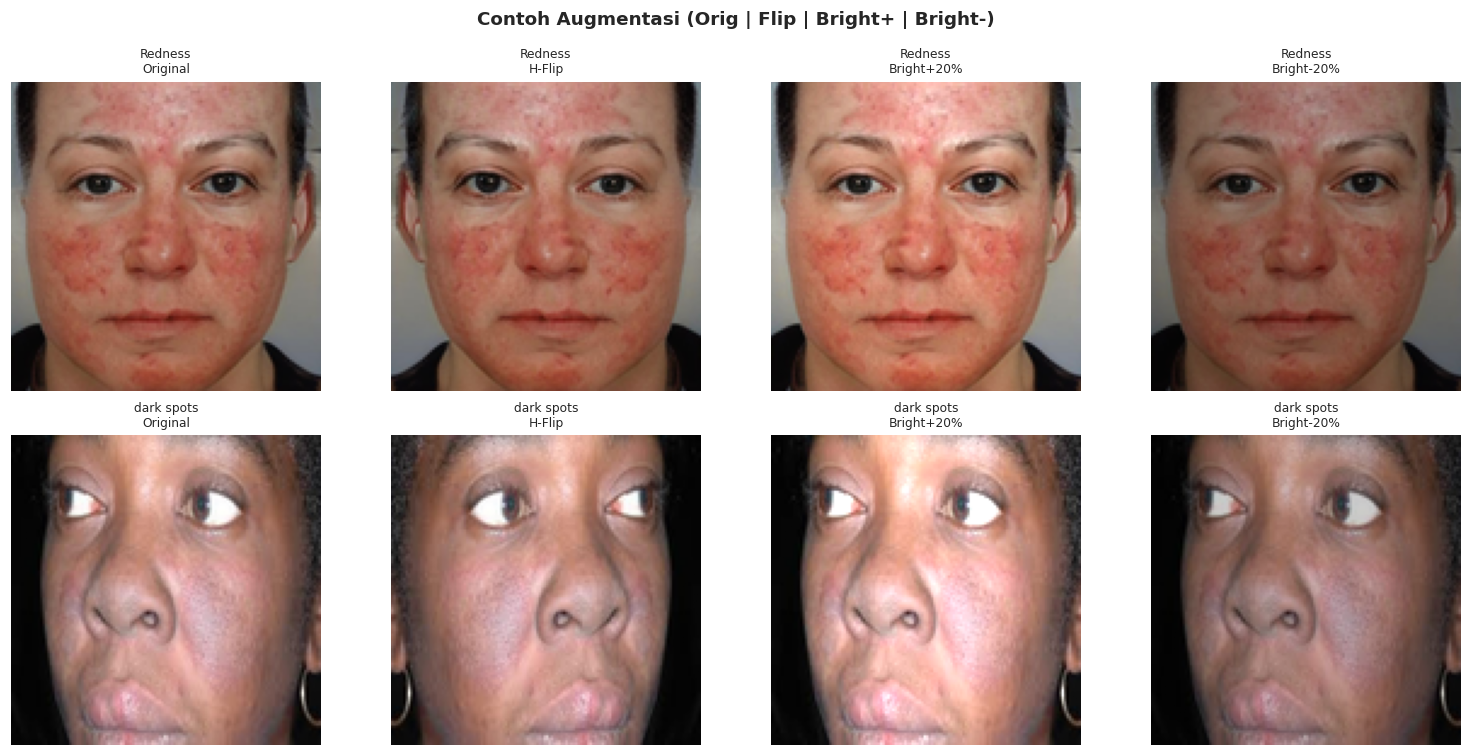

Contoh augmentasi disimpan.


In [6]:
# Visualisasi contoh augmentasi
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Contoh Augmentasi (Orig | Flip | Bright+ | Bright-)', fontsize=12, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES[:2]):
    idx = np.where(lbls_train_orig == cls)[0][0]
    orig_img = imgs_train_orig[idx]
    aug_imgs = augment_image(orig_img)

    for col, (img, title) in enumerate(zip(
        [orig_img] + aug_imgs,
        ['Original', 'H-Flip', 'Bright+20%', 'Bright-20%']
    )):
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'{cls[:15]}\n{title}', fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'augmentation_examples.png', bbox_inches='tight')
plt.show()
print('Contoh augmentasi disimpan.')


In [7]:
# ============================================================
# SECTION 4: Feature Extraction
# ============================================================

# ─── HOG 16×16 ───────────────────────────────────────────────
def extract_hog(img_gray: np.ndarray) -> np.ndarray:
    return hog(img_gray, orientations=9, pixels_per_cell=(16,16),
               cells_per_block=(2,2), block_norm='L2-Hys', feature_vector=True)

# ─── Multi-scale LBP ─────────────────────────────────────────
def extract_lbp(img_gray: np.ndarray) -> np.ndarray:
    """
    LBP pada 3 radius (R=1,2,3) — masing-masing 26 bin → 78 total.
    R kecil: pola tekstur sangat lokal (pori, bintik halus)
    R besar: pola tekstur lebih luas (keriput, area jerawat)
    FIX: normalize ke true probability (bukan density)
    """
    feats = []
    for R in [1, 2, 3]:
        P   = 8 * R
        lbp = local_binary_pattern(img_gray, P=P, R=R, method='uniform')
        n   = P + 2
        counts, _ = np.histogram(lbp.ravel(), bins=n, range=(0, n))
        feats.append((counts / (counts.sum() + 1e-8)).astype(np.float32))
    return np.concatenate(feats)

# ─── Color Moments ───────────────────────────────────────────
def extract_color_moments(img_rgb: np.ndarray) -> np.ndarray:
    """
    Mean + Std + Skewness per channel: RGB(3) + HSV(3) + LAB(3) = 9 channel × 3 = 27 fitur.
    
    Sangat berguna untuk kondisi kulit:
      - R channel mean tinggi + H channel (Hue) merah → Redness/Inflamasi
      - S channel tinggi → Pigmentasi saturasi
      - L* (LAB) → luminance/kecerahan kulit
      - A* (LAB) → hijau↔merah axis, sangat relevan untuk kemerahan
      - Skewness → distribusi asimetris (bintik gelap, area merah terlokalisir)
    
    Semua dinormalisasi ke [0,1].
    """
    feats = []

    # RGB (sudah [0,1])
    for ch in range(3):
        c = img_rgb[:,:,ch].ravel()
        s = float(skew(c))
        feats += [float(c.mean()), float(c.std()), float(np.clip((s+3)/6, 0, 1))]

    # HSV
    img_u8  = (img_rgb * 255).astype(np.uint8)
    img_hsv = np.array(Image.fromarray(img_u8).convert('HSV'),
                        dtype=np.float32) / 255.0
    for ch in range(3):
        c = img_hsv[:,:,ch].ravel()
        s = float(skew(c))
        feats += [float(c.mean()), float(c.std()), float(np.clip((s+3)/6, 0, 1))]

    # LAB (L:0-100, A:-128-127, B:-128-127)
    img_lab = rgb2lab(img_rgb)
    ranges  = [(0,100), (-128,127), (-128,127)]
    for ch, (lo, hi) in enumerate(ranges):
        c_raw = img_lab[:,:,ch].ravel()
        c     = np.clip((c_raw - lo) / (hi - lo + 1e-8), 0, 1)
        s     = float(skew(c_raw))
        feats += [float(c.mean()), float(c.std()), float(np.clip((s+3)/6, 0, 1))]

    return np.array(feats, dtype=np.float32)

# ─── Color Histogram (FIXED) ─────────────────────────────────
def extract_color_histogram(img_rgb: np.ndarray) -> np.ndarray:
    """
    Histogram RGB + HSV, 8 bins per channel = 48 fitur.
    FIX KRITIS: counts/sum bukan density=True
    density=True menghasilkan probability DENSITY yang bisa >> 1
    counts/sum menghasilkan true probability selalu [0,1]
    """
    feats = []
    for ch in range(3):
        counts, _ = np.histogram(img_rgb[:,:,ch].ravel(),
                                  bins=8, range=(0.0, 1.0))
        feats.append((counts / (counts.sum() + 1e-8)).astype(np.float32))

    img_u8  = (img_rgb * 255).astype(np.uint8)
    img_hsv = np.array(Image.fromarray(img_u8).convert('HSV'),
                        dtype=np.float32) / 255.0
    for ch in range(3):
        counts, _ = np.histogram(img_hsv[:,:,ch].ravel(),
                                  bins=8, range=(0.0, 1.0))
        feats.append((counts / (counts.sum() + 1e-8)).astype(np.float32))

    return np.concatenate(feats)

# ─── Gabor ───────────────────────────────────────────────────
_GLCM_RANGES = {
    'contrast'     : (0.0, 63.0),
    'dissimilarity': (0.0, 63.0),
    'homogeneity'  : (0.0, 1.0),
    'energy'       : (0.0, 1.0),
    'correlation'  : (-1.0, 1.0),
    'ASM'          : (0.0, 1.0),
}

def extract_gabor(img_gray: np.ndarray) -> np.ndarray:
    feats = []
    for freq in [0.1, 0.2, 0.3, 0.4]:
        for i in range(6):
            theta  = i * np.pi / 6
            kernel = np.real(gabor_kernel(freq, theta=theta, sigma_x=1, sigma_y=1))
            filt   = np.clip(np.abs(convolve(img_gray, kernel, mode='wrap')), 0, 1)
            feats += [float(filt.mean()), float(filt.std())]
    return np.array(feats, dtype=np.float32)

# ─── GLCM (normalized) ───────────────────────────────────────
def extract_glcm(img_gray: np.ndarray) -> np.ndarray:
    img_q = (img_gray * 255).astype(np.uint8) // 4
    feats = []
    props = ['contrast','dissimilarity','homogeneity','energy','correlation','ASM']
    for dist in [1, 3]:
        glcm = graycomatrix(img_q, distances=[dist],
                            angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                            levels=64, symmetric=True, normed=True)
        for prop in props:
            vals   = graycoprops(glcm, prop)[0]
            lo, hi = _GLCM_RANGES[prop]
            normed = np.clip((vals - lo) / (hi - lo + 1e-8), 0, 1)
            feats += [float(normed.mean()), float(normed.std())]
    return np.array(feats, dtype=np.float32)

# ─── Full pipeline ────────────────────────────────────────────
def extract_features(img_rgb: np.ndarray) -> np.ndarray:
    gray = rgb2gray(img_rgb).astype(np.float32)
    return np.concatenate([
        extract_hog(gray),              # 1764
        extract_lbp(gray),              # 78
        extract_color_moments(img_rgb), # 27
        extract_color_histogram(img_rgb),# 48
        extract_gabor(gray),            # 48
        extract_glcm(gray),             # 24
    ])

# Validasi range
s   = imgs_train_orig[0]
sg  = rgb2gray(s).astype(np.float32)
hog_dim = extract_hog(sg).shape[0]
lbp_dim = extract_lbp(sg).shape[0]
cm_dim  = extract_color_moments(s).shape[0]
ch_dim  = extract_color_histogram(s).shape[0]
gab_dim = extract_gabor(sg).shape[0]
glcm_dim= extract_glcm(sg).shape[0]
total   = hog_dim+lbp_dim+cm_dim+ch_dim+gab_dim+glcm_dim

print('Feature functions defined.')
print()
print('Dimensi & Range Fitur:')
print(f'   HOG  16×16       : {hog_dim:>5} | [{extract_hog(sg).min():.3f}, {extract_hog(sg).max():.3f}]')
print(f'   LBP  multi       : {lbp_dim:>5} | [{extract_lbp(sg).min():.3f}, {extract_lbp(sg).max():.3f}] ')
print(f'   Color Moments    : {cm_dim:>5} | [{extract_color_moments(s).min():.3f}, {extract_color_moments(s).max():.3f}]  ')
ch_f = extract_color_histogram(s)
print(f'   Color Hist (fix) : {ch_dim:>5} | [{ch_f.min():.3f}, {ch_f.max():.3f}] ')
print(f'   Gabor            : {gab_dim:>5} | [{extract_gabor(sg).min():.3f}, {extract_gabor(sg).max():.3f}] ')
print(f'   GLCM             : {glcm_dim:>5} | [{extract_glcm(sg).min():.3f}, {extract_glcm(sg).max():.3f}] ')
print(f'   {"─"*45}')
print(f'   TOTAL            : {total:>5}')


Feature functions defined.

Dimensi & Range Fitur:
   HOG  16×16       :  1764 | [0.010, 0.661]
   LBP  multi       :    54 | [0.009, 0.513] 
   Color Moments    :    27 | [0.000, 1.000]  
   Color Hist (fix) :    48 | [0.000, 0.992] 
   Gabor            :    48 | [0.007, 0.419] 
   GLCM             :    24 | [0.000, 0.949] 
   ─────────────────────────────────────────────
   TOTAL            :  1965


In [8]:
# ─── Ekstrak fitur train (augmented) + test ───────────────────
print(f'Mengekstrak fitur train ({len(imgs_train_aug)} gambar termasuk augmentasi)...')
t0 = time.time()
X_train = np.array(
    [extract_features(im) for im in tqdm(imgs_train_aug, desc='Train', leave=True)],
    dtype=np.float32
)
print(f'   Train selesai: {time.time()-t0:.1f}s | shape={X_train.shape}')

print(f'\nMengekstrak fitur test ({len(imgs_test)} gambar)...')
t0 = time.time()
X_test = np.array(
    [extract_features(im) for im in tqdm(imgs_test, desc='Test', leave=True)],
    dtype=np.float32
)
print(f'   Test selesai: {time.time()-t0:.1f}s | shape={X_test.shape}')

# Bersihkan NaN/Inf
X_train = np.nan_to_num(X_train, nan=0.0, posinf=1.0, neginf=0.0)
X_test  = np.nan_to_num(X_test,  nan=0.0, posinf=1.0, neginf=0.0)
print('\nEkstraksi fitur selesai.')


Mengekstrak fitur train (13544 gambar termasuk augmentasi)...


Train:   0%|          | 0/13544 [00:00<?, ?it/s]

   Train selesai: 1023.7s | shape=(13544, 1965)

Mengekstrak fitur test (847 gambar)...


Test:   0%|          | 0/847 [00:00<?, ?it/s]

   Test selesai: 64.2s | shape=(847, 1965)

Ekstraksi fitur selesai.


In [9]:
# EDA pada train set original (non-augmented) agar tidak bias
y_orig_train = le.transform(lbls_train_orig)

feat_groups = {
    'HOG 16×16'     : (0, hog_dim),
    'LBP multi'     : (hog_dim, hog_dim+lbp_dim),
    'Color Moments' : (hog_dim+lbp_dim, hog_dim+lbp_dim+cm_dim),
    'Color Hist'    : (hog_dim+lbp_dim+cm_dim, hog_dim+lbp_dim+cm_dim+ch_dim),
    'Gabor'         : (hog_dim+lbp_dim+cm_dim+ch_dim, hog_dim+lbp_dim+cm_dim+ch_dim+gab_dim),
    'GLCM'          : (total-glcm_dim, total),
}

# Ambil hanya bagian original dari X_train (bukan augmented)
X_orig_only = X_train[:len(imgs_train_orig)]

print('EDA per Grup (train original):')
print(f'   {"Grup":<18}  {"mean":>6}  {"max":>6}  {"CV":>8}  Status')
print('   ' + '─'*60)
for gname, (s, e) in feat_groups.items():
    gdata = X_orig_only[:, s:e]
    class_means = np.array([gdata[y_orig_train == c].mean()
                             for c in np.unique(y_orig_train)])
    cv  = class_means.std() / (class_means.mean() + 1e-8)
    tag = '✅' if cv > 0.02 else '⚠️  rendah'
    print(f'   {gname:<18}  {gdata.mean():>6.4f}  {gdata.max():>6.4f}  {cv:>8.4f}  {tag}')


EDA per Grup (train original):
   Grup                  mean     max        CV  Status
   ────────────────────────────────────────────────────────────
   HOG 16×16           0.1423  1.0000    0.0352  ✅
   LBP multi           0.0556  0.8897    0.0000  ⚠️  rendah
   Color Moments       0.3648  1.0000    0.0288  ✅
   Color Hist          0.1250  1.0000    0.0000  ⚠️  rendah
   Gabor               0.1260  0.7404    0.0309  ✅
   GLCM                0.1685  1.0000    0.0522  ✅


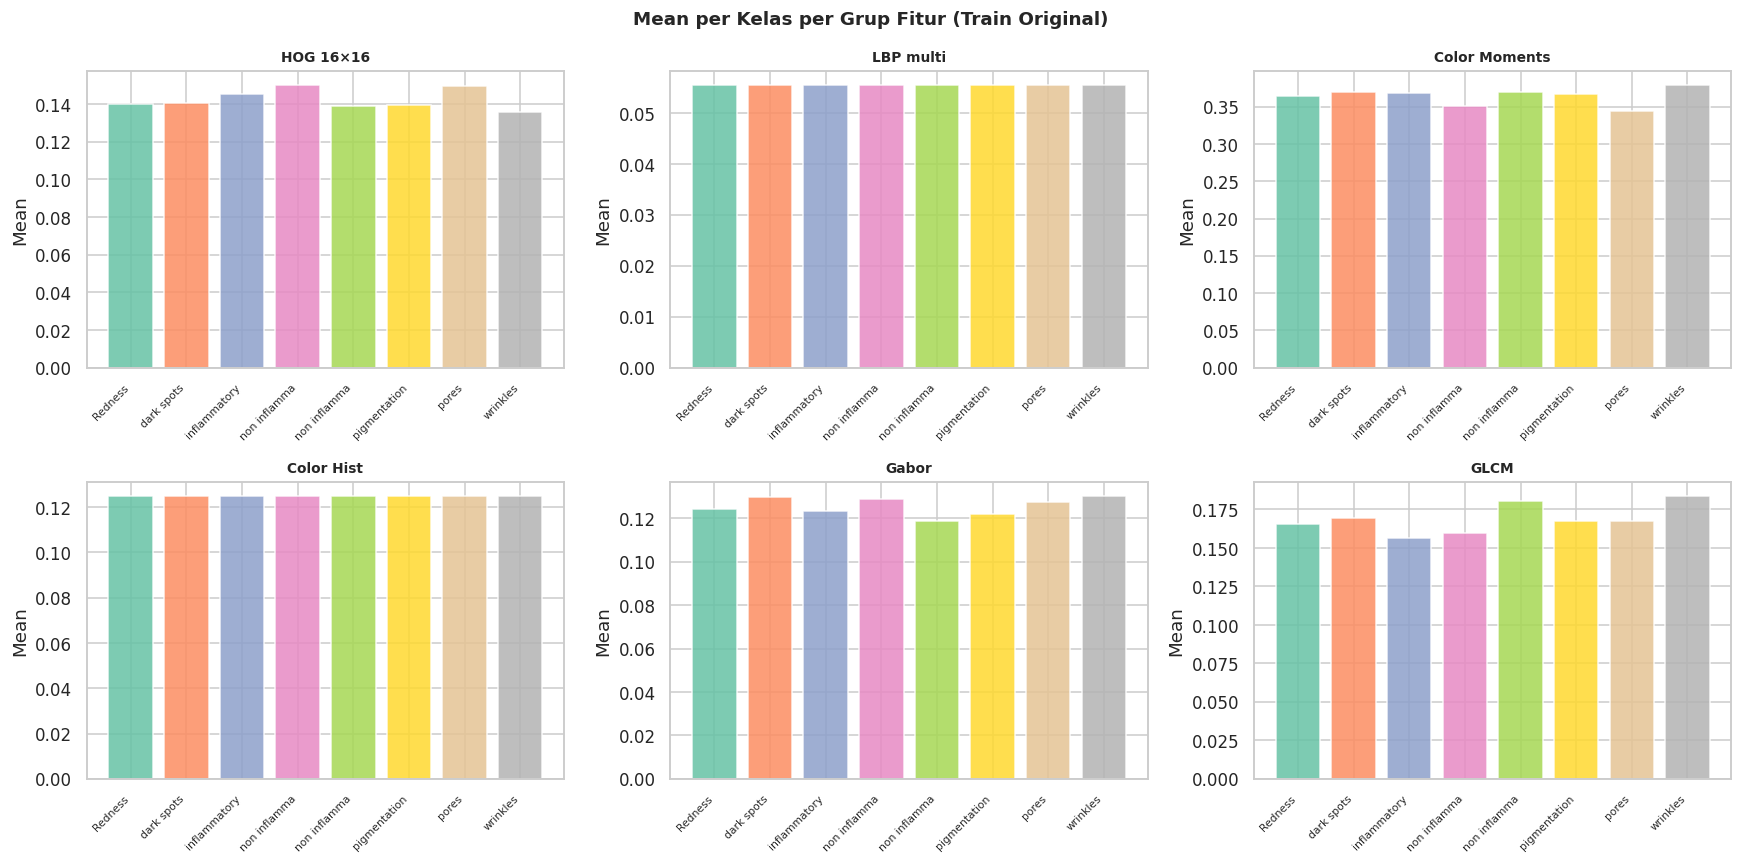

EDA disimpan.


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Mean per Kelas per Grup Fitur (Train Original)', fontsize=12, fontweight='bold')
colors = sns.color_palette('Set2', NUM_CLASSES)
short  = [c[:12] for c in le.classes_]

for ax, (gname, (s, e)) in zip(axes.flat, feat_groups.items()):
    gdata       = X_orig_only[:, s:e]
    class_means = [gdata[y_orig_train == c].mean() for c in range(NUM_CLASSES)]
    ax.bar(range(NUM_CLASSES), class_means, color=colors, alpha=0.85)
    ax.set_title(gname, fontsize=9, fontweight='bold')
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(short, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Mean')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_v4.png', bbox_inches='tight')
plt.show()
print('EDA disimpan.')


In [11]:
# ============================================================
# SECTION 5: Scaling → PCA → Feature Selection
# ============================================================
artifacts = {}

# ─── 5.1 StandardScaler ──────────────────────────────────────
print('Step 1: StandardScaler...')
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
artifacts['scaler'] = scaler
print(f'   shape={X_train_sc.shape}')

# ─── 5.2 PCA ─────────────────────────────────────────────────
# Pertahankan 95% variance — dimensi berkurang drastis
print()
print('Step 2: PCA (90% variance)...')
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)
artifacts['pca'] = pca
print(f'   {X_train_sc.shape[1]} → {X_train_pca.shape[1]} dim | '
      f'variance={pca.explained_variance_ratio_.sum()*100:.1f}%')

# ─── 5.3 Feature Selection (SelectKBest + mutual_info) ───────
# mutual_info_classif mengukur seberapa banyak info yang dibawa tiap fitur
# tentang label kelas — fitur dengan MI rendah = noise, dibuang
print()
print('Step 3: Feature Selection (SelectKBest, mutual_info_classif)...')
print('   (ini butuh ~2-3 menit...)')

# Ambil top 50% fitur berdasarkan mutual information dengan label
k_features = int(X_train_pca.shape[1] * 0.50)
selector   = SelectKBest(mutual_info_classif, k=k_features)
X_train_sel = selector.fit_transform(X_train_pca, y_train)
X_test_sel  = selector.transform(X_test_pca)
artifacts['selector'] = selector
artifacts['le']       = le

print(f'   {X_train_pca.shape[1]} → {X_train_sel.shape[1]} fitur terpilih (top 50%)')
print()
print(f'Shape akhir masuk model: train={X_train_sel.shape}, test={X_test_sel.shape}')

# Simpan semua artifacts
with open(OUTPUT_DIR / 'artifacts_v4.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
with open(OUTPUT_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('artifacts_v4.pkl tersimpan.')


Step 1: StandardScaler...
   shape=(13544, 1965)

Step 2: PCA (90% variance)...
   1965 → 317 dim | variance=90.0%

Step 3: Feature Selection (SelectKBest, mutual_info_classif)...
   (ini butuh ~2-3 menit...)
   317 → 158 fitur terpilih (top 50%)

Shape akhir masuk model: train=(13544, 158), test=(847, 158)
artifacts_v4.pkl tersimpan.


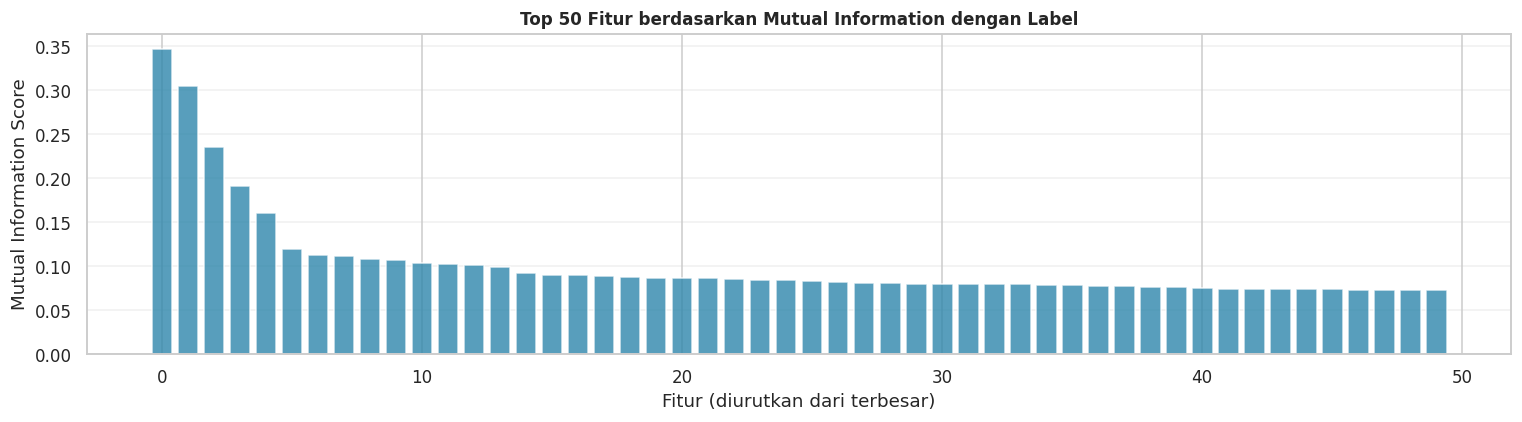

MI scores: max=0.3470, mean=0.0574, min=0.0223
   Fitur dibuang (MI rendah): 159


In [12]:
# --- Visualisasi mutual information score ---
mi_scores = selector.scores_
n_show    = min(50, len(mi_scores))
top_idx   = np.argsort(mi_scores)[::-1][:n_show]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(n_show), mi_scores[top_idx], color='#2E86AB', alpha=0.8)
ax.set_title(f'Top {n_show} Fitur berdasarkan Mutual Information dengan Label',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Fitur (diurutkan dari terbesar)')
ax.set_ylabel('Mutual Information Score')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mutual_info_scores.png', bbox_inches='tight')
plt.show()
print(f'MI scores: max={mi_scores.max():.4f}, mean={mi_scores.mean():.4f}, min={mi_scores.min():.4f}')
print(f'   Fitur dibuang (MI rendah): {X_train_pca.shape[1] - X_train_sel.shape[1]}')


In [13]:
baseline_models = {
    'SVM (RBF)': SVC(kernel='rbf', probability=False,
                     class_weight='balanced', random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB(var_smoothing=1e-9),
    'Decision Tree': DecisionTreeClassifier(criterion='gini', class_weight='balanced',
                                             random_state=RANDOM_STATE),
}
baseline_results = {}

print('Baseline training (fitur v4: augmented + feature selection)...')
print('=' * 62)
for name, model in baseline_models.items():
    t0 = time.time()
    model.fit(X_train_sel, y_train)
    tr_t  = time.time() - t0
    t0    = time.time()
    y_pred= model.predict(X_test_sel)
    pr_t  = time.time() - t0
    acc   = accuracy_score(y_test, y_pred)
    f1    = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    baseline_results[name] = {'model':model,'y_pred':y_pred,'accuracy':acc,'f1_weighted':f1}
    print(f'  [{name:<18}]  Acc={acc:.4f}  F1={f1:.4f}  Train={tr_t:.1f}s')
print('=' * 62)


Baseline training (fitur v4: augmented + feature selection)...
  [SVM (RBF)         ]  Acc=0.7946  F1=0.7954  Train=14.3s
  [Naive Bayes       ]  Acc=0.4545  F1=0.4510  Train=0.0s
  [Decision Tree     ]  Acc=0.5396  F1=0.5428  Train=6.7s


In [14]:
cv3 = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

tuned_models = {}

print('[1/3] Tuning SVM...')

svm_search = RandomizedSearchCV(
    SVC(
        kernel='rbf',                  
        probability=True,            
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),

    param_distributions={
        'C': [1, 5, 10, 20, 50],
        'gamma': ['scale', 0.001, 0.01]
    },

    n_iter=10,
    cv=cv3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

t0 = time.time()

svm_search.fit(X_train_sel, y_train)

print(
    f'   Selesai {time.time()-t0:.1f}s | '
    f'Best: {svm_search.best_params_} | '
    f'CV F1={svm_search.best_score_:.4f}'
)

tuned_models['SVM (RBF)'] = svm_search.best_estimator_

[1/3] Tuning SVM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
   Selesai 1151.2s | Best: {'gamma': 0.001, 'C': 50} | CV F1=0.9340


In [15]:
print('[2/3] Tuning Naive Bayes...')
nb_search = GridSearchCV(
    GaussianNB(),
    param_grid={'var_smoothing': np.logspace(-12, -1, 24)},
    cv=cv3, scoring='f1_weighted', n_jobs=-1
)
t0 = time.time()
nb_search.fit(X_train_sel, y_train)
print(f'   Selesai {time.time()-t0:.1f}s | Best: {nb_search.best_params_} | CV F1={nb_search.best_score_:.4f}')
tuned_models['Naive Bayes'] = nb_search.best_estimator_


[2/3] Tuning Naive Bayes...
   Selesai 1.8s | Best: {'var_smoothing': np.float64(1.492495545051829e-05)} | CV F1=0.4921


In [16]:
print('[3/3] Tuning Decision Tree...')
dt_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid={
        'max_depth'        : [10, 20, 30, 50, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4],
        'criterion'        : ['gini', 'entropy'],
        'max_features'     : ['sqrt', 'log2', None],
    },
    cv=cv3, scoring='f1_weighted', n_jobs=-1
)
t0 = time.time()
dt_search.fit(X_train_sel, y_train)
print(f'   Selesai {time.time()-t0:.1f}s | Best: {dt_search.best_params_} | CV F1={dt_search.best_score_:.4f}')
tuned_models['Decision Tree'] = dt_search.best_estimator_
print('\nTuning selesai.')


[3/3] Tuning Decision Tree...
   Selesai 559.9s | Best: {'criterion': 'entropy', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2} | CV F1=0.6908

Tuning selesai.


In [17]:
def evaluate(name, model, X_t, y_t):
    y_pred = model.predict(X_t)
    return {
        'Model': name,
        'Accuracy'     : accuracy_score(y_t, y_pred),
        'Precision'    : precision_score(y_t, y_pred, average='weighted', zero_division=0),
        'Recall'       : recall_score(y_t, y_pred, average='weighted', zero_division=0),
        'F1 (weighted)': f1_score(y_t, y_pred, average='weighted', zero_division=0),
        'y_pred': y_pred, 'model_obj': model,
    }

all_eval = {}
for name, info in baseline_results.items():
    r = evaluate(f'{name} (Baseline)', info['model'], X_test_sel, y_test)
    all_eval[r['Model']] = r
for name, model in tuned_models.items():
    r = evaluate(f'{name} (Tuned)', model, X_test_sel, y_test)
    all_eval[r['Model']] = r

df_cols = ['Model','Accuracy','Precision','Recall','F1 (weighted)']
eval_df = pd.DataFrame([{k:v for k,v in r.items() if k in df_cols} for r in all_eval.values()])
eval_df = eval_df.sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)

print('=' * 88)
print('HASIL EVALUASI v4')
print('=' * 88)
print(eval_df.to_string(index=False, float_format='{:.4f}'.format))


HASIL EVALUASI v4
                   Model  Accuracy  Precision  Recall  F1 (weighted)
       SVM (RBF) (Tuned)    0.8017     0.8088  0.8017         0.8026
    SVM (RBF) (Baseline)    0.7946     0.7988  0.7946         0.7954
Decision Tree (Baseline)    0.5396     0.5486  0.5396         0.5428
   Decision Tree (Tuned)    0.5171     0.5252  0.5171         0.5197
  Naive Bayes (Baseline)    0.4545     0.4814  0.4545         0.4510
     Naive Bayes (Tuned)    0.4545     0.4814  0.4545         0.4510


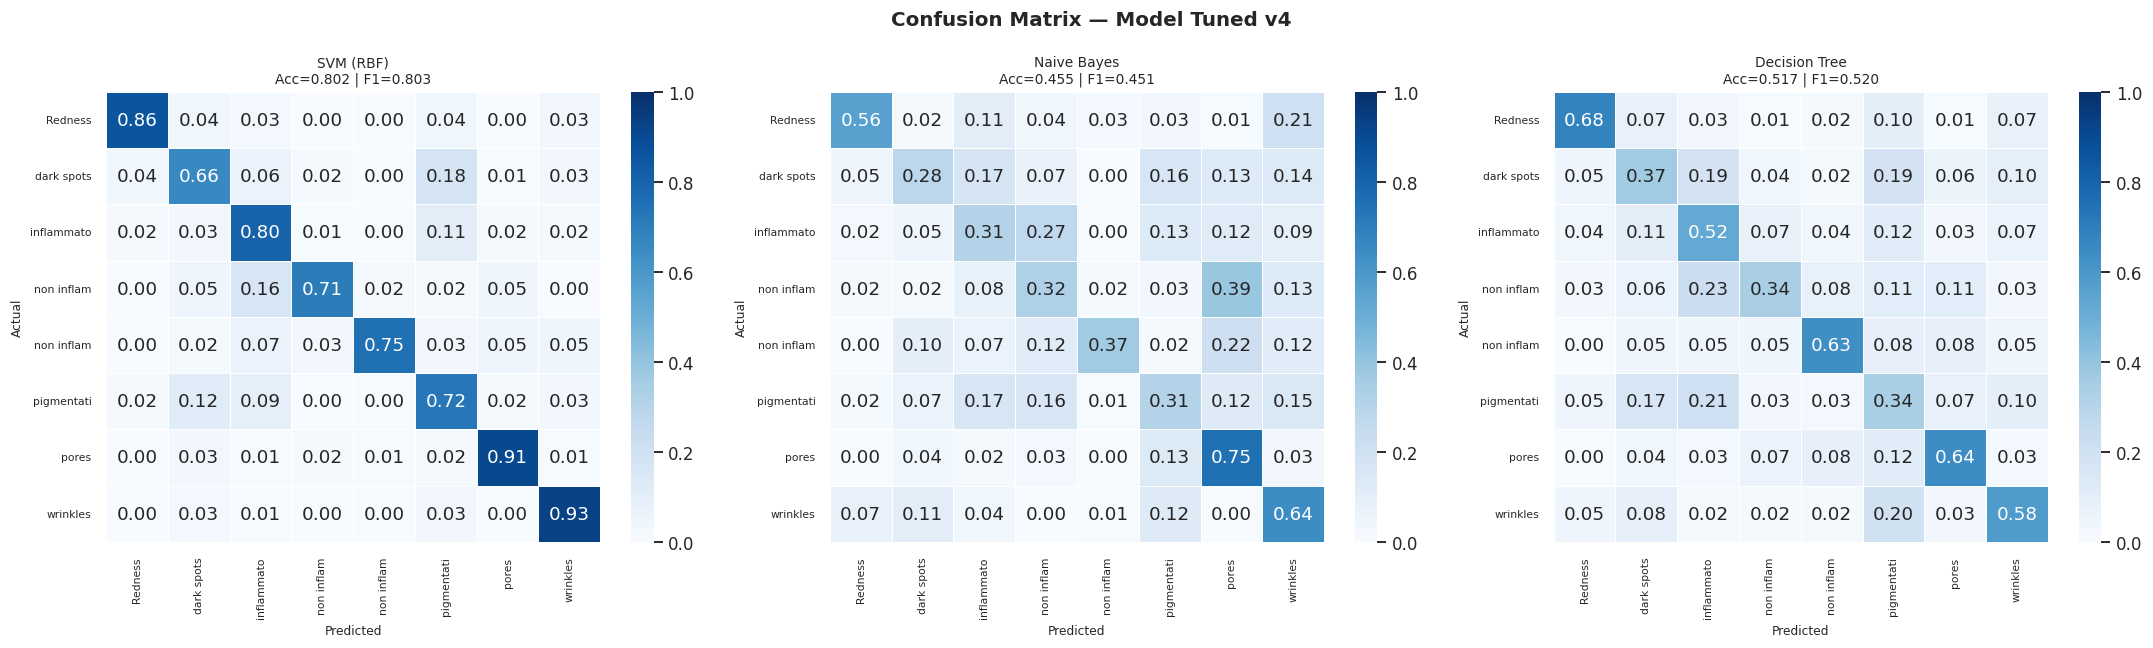

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrix — Model Tuned v4', fontsize=13, fontweight='bold')
short = [c[:10] for c in le.classes_]

for ax, (name, model) in zip(axes, tuned_models.items()):
    y_pred = model.predict(X_test_sel)
    cm_n   = confusion_matrix(y_test, y_pred).astype(float)
    cm_n  /= cm_n.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.2f', ax=ax,
                xticklabels=short, yticklabels=short,
                cmap='Blues', vmin=0, vmax=1, linewidths=0.5)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    ax.set_title(f'{name}\nAcc={acc:.3f} | F1={f1:.3f}', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=8); ax.set_ylabel('Actual', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices_v4.png', bbox_inches='tight')
plt.show()


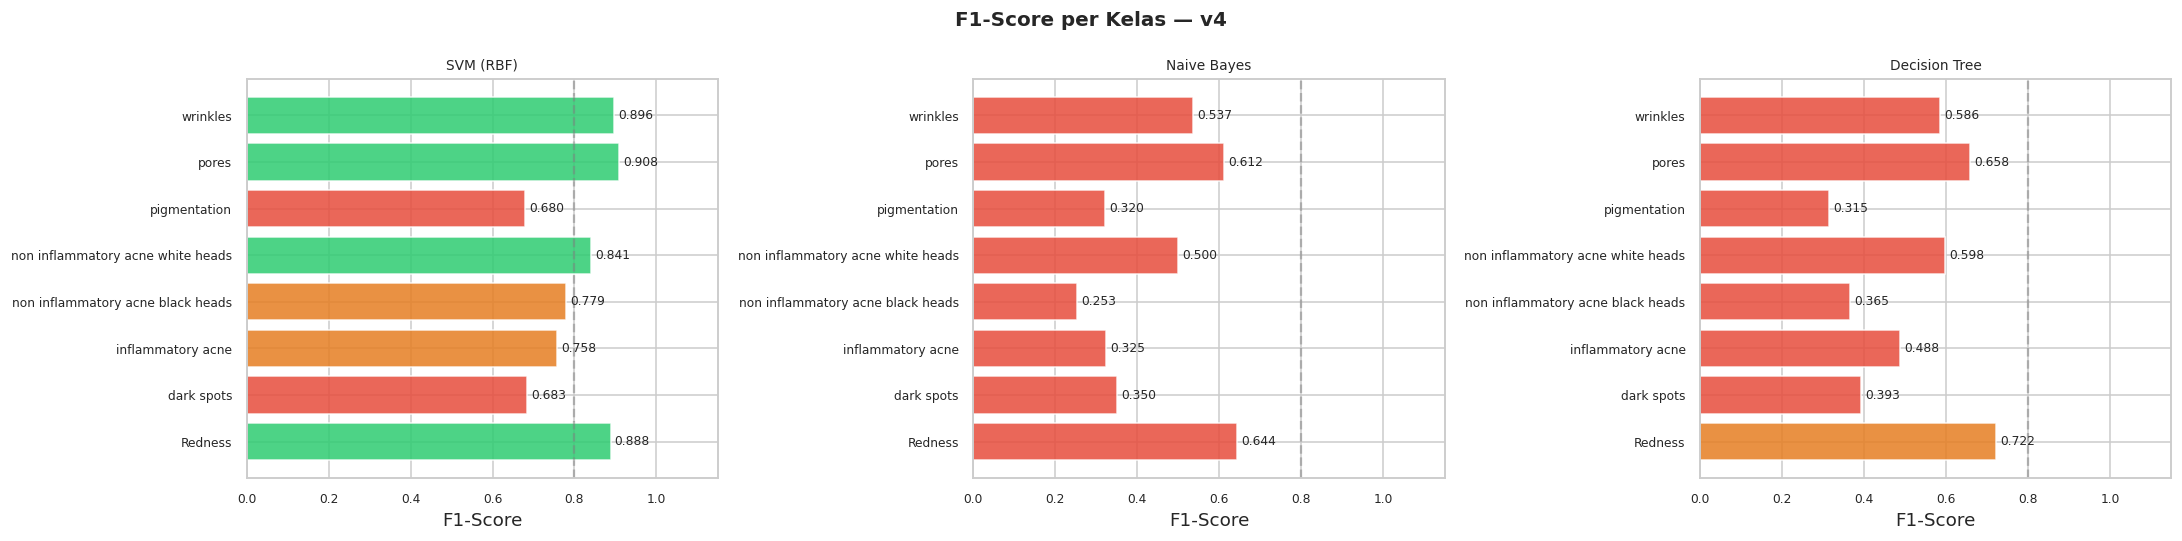

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('F1-Score per Kelas — v4', fontsize=13, fontweight='bold')
for ax, (name, model) in zip(axes, tuned_models.items()):
    y_pred = model.predict(X_test_sel)
    f1_per = f1_score(y_test, y_pred, average=None, zero_division=0)
    bc = ['#E74C3C' if f<0.70 else '#E67E22' if f<0.80 else '#2ECC71' for f in f1_per]
    ax.barh(le.classes_, f1_per, color=bc, alpha=0.85, edgecolor='white')
    ax.axvline(0.80, linestyle='--', color='gray', alpha=0.5)
    for i,v in enumerate(f1_per): ax.text(v+0.01, i, f'{v:.3f}', va='center', fontsize=8)
    ax.set_xlabel('F1-Score'); ax.set_title(name, fontsize=9)
    ax.set_xlim(0, 1.15); ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'f1_per_class_v4.png', bbox_inches='tight')
plt.show()


In [20]:
ranking_df = eval_df.sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)

print('RANKING:')
print('='*88)
for i, row in ranking_df.iterrows():
    medal = ['🥇','🥈','🥉'][i] if i < 3 else f'  {i+1}.'
    print(f'   {medal}  [{row["Model"]:<42}]  Acc={row["Accuracy"]:.4f}  F1={row["F1 (weighted)"]:.4f}')
print('='*88)

best_name      = ranking_df.iloc[0]['Model']
best_acc       = ranking_df.iloc[0]['Accuracy']
best_f1        = ranking_df.iloc[0]['F1 (weighted)']
best_model_obj = all_eval[best_name]['model_obj']
y_pred_best    = all_eval[best_name]['y_pred']

print(f'\n🥇 Best: {best_name}')
print(f'   Accuracy: {best_acc*100:.2f}%')
print(f'   F1      : {best_f1:.4f}')
print(f'   vs v2   : +{(best_acc-0.778)*100:.1f}%')
print()
print(classification_report(y_test, y_pred_best,
      target_names=le.classes_, digits=4, zero_division=0))


RANKING:
   🥇  [SVM (RBF) (Tuned)                         ]  Acc=0.8017  F1=0.8026
   🥈  [SVM (RBF) (Baseline)                      ]  Acc=0.7946  F1=0.7954
   🥉  [Decision Tree (Baseline)                  ]  Acc=0.5396  F1=0.5428
     4.  [Decision Tree (Tuned)                     ]  Acc=0.5171  F1=0.5197
     5.  [Naive Bayes (Baseline)                    ]  Acc=0.4545  F1=0.4510
     6.  [Naive Bayes (Tuned)                       ]  Acc=0.4545  F1=0.4510

🥇 Best: SVM (RBF) (Tuned)
   Accuracy: 80.17%
   F1      : 0.8026
   vs v2   : +2.4%

                                   precision    recall  f1-score   support

                          Redness     0.9196    0.8583    0.8879       120
                       dark spots     0.7069    0.6613    0.6833       124
                inflammatory acne     0.7185    0.8017    0.7578       121
non inflammatory acne black heads     0.8627    0.7097    0.7788        62
non inflammatory acne white heads     0.9574    0.7500    0.8411        60


In [21]:
# Simpan
with open(OUTPUT_DIR / 'best_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)

meta = {
    'version'          : 'v4',
    'best_model_name'  : best_name,
    'accuracy'         : float(best_acc),
    'f1_weighted'      : float(best_f1),
    'img_size'         : list(IMG_SIZE),
    'augmentation'     : 'flip_h + brightness_1.2 + brightness_0.8 (train only)',
    'feature_pipeline' : 'HOG16 + LBP_multi(R=1,2,3) + ColorMoments(RGB+HSV+LAB) + ColorHist(fixed) + Gabor + GLCM',
    'feature_dim_raw'  : int(X_train.shape[1]),
    'feature_dim_final': int(X_train_sel.shape[1]),
    'pca_components'   : int(pca.n_components_),
    'pca_variance'     : float(pca.explained_variance_ratio_.sum()),
    'kbest_k'          : int(selector.k),
    'classes'          : list(le.classes_),
    'preprocessing_order': [
        '1. load_and_preprocess(path, IMG_SIZE)  # NO augmentation pada inference',
        '2. extract_features(img)                # HOG+LBP+CM+CH+Gabor+GLCM',
        '3. artifacts[scaler].transform([feats])',
        '4. artifacts[pca].transform()',
        '5. artifacts[selector].transform()',
        '6. best_model.predict()',
        '7. le.inverse_transform()',
    ]
}
with open(OUTPUT_DIR / 'model_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Artefak tersimpan:')
for fname in ['best_model.pkl','artifacts_v4.pkl','label_encoder.pkl','model_metadata.json']:
    p = OUTPUT_DIR / fname
    if p.exists():
        print(f'   {fname:<35} ({p.stat().st_size/1024:.1f} KB)')


Artefak tersimpan:
   best_model.pkl                      (11189.0 KB)
   artifacts_v4.pkl                    (2495.6 KB)
   label_encoder.pkl                   (1.3 KB)
   model_metadata.json                 (1.1 KB)
